# 1. Driven Kerr cavity: loops, mean field, and an asymptotic series — Fig. 5 (Sec. V.A)

**Problem.** $H=\Delta_c a^\dagger a+i(\eta a^\dagger-\eta^*a)+\tfrac U2 (a^\dagger)^2a^2$ with $\kappa\mathcal D[a]$, $\Delta_c=-\kappa$, $\eta=\kappa$, so $|\alpha|^2=0.8$.

**Set-up.** The drive is removed exactly by $b=a-\alpha$, $\alpha=\eta/z$; $\mathcal L_0$ is the damped mode with a vacuum steady state and the Kerr term is the perturbation. Mean-field theory is the sum of all loop-free ($L=0$) contributions, so the gap between the two curves is the loop content. The series is asymptotic: the error falls to a minimum at an optimal order that shrinks as $U$ grows. The paper truncates every series where successive partial sums differ least (Eq. truncrule) and quotes that difference as the error bar $\delta$.

**Part A** runs the calculation here (diagram series, exact steady state, mean field). **Part B** regenerates Fig. 5 of the paper from `benchmarks/truncation/kerr_truncation.json` (series through $N=16$ with the exact reference, written by `kerr_trunc.py`, ~1 min) and prints the numbers quoted in Sec. V.A.

In [1]:
from common import *
FAST = True      # True: reduced orders and cutoffs, minutes.  False: the orders and cutoffs of the paper (see the runtime note)
print("repository:", os.path.basename(CODE), "| FAST =", FAST, "| paper sources:", "found" if PAPER else "not present (Tables V and SI from notebooks/paper_reference/)")

repository: gh_staging | FAST = True | paper sources: not present (Tables V and SI from notebooks/paper_reference/)


## Part A — the calculation

U=0.05: error minimum at N=12 (1.15e-09), error at N=12: 1.15e-09
U=0.1: error minimum at N=12 (1.34e-05), error at N=12: 1.34e-05
U=0.2: error minimum at N=9 (1.94e-02), error at N=12: 1.23e-01
U=0.3: error minimum at N=5 (1.63e-01), error at N=12: 1.70e+01


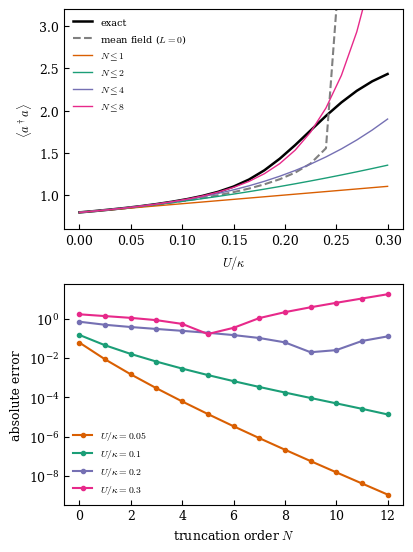


mean field vs exact: U=0.2: 1.215 vs 1.485   U=0.3: 3.76 vs 2.43   (paper: 1.215 vs 1.485; 3.76 vs 2.43)
root test |c_N|^(-1/N) at N=10: 0.27  (paper: 0.27, falling to 0.15 at N=40)


In [2]:
kappa, Dc, eta = 1.0, -1.0, 1.0
z = kappa/2 + 1j*Dc; alpha = eta/z
a, ad, b, bd = mode_ops(alpha)
mod = Model(1, z, lambda X: 0*X, np.eye(1), scale(0.5, mul(mul(ad,ad), mul(a,a))), 4)
Nmax = 12 if FAST else 16
cn = moment_series(mod, 1, 1, alpha, Nmax).real          # coefficients of <a^dag a> = sum_N c_N U^N
def kerr_exact(U, Nc=30):
    A = destroy(Nc); Ad = A.conj().T
    H = Dc*Ad@A + 1j*(eta*Ad - np.conj(eta)*A) + U/2*Ad@Ad@A@A
    rho = steady(H, [np.sqrt(kappa)*A]); return np.trace(Ad@A@rho).real
def kerr_meanfield(U):
    r = np.roots([U**2, 2*Dc*U, Dc**2+kappa**2/4, -abs(eta)**2]) if U>0 else [abs(alpha)**2]
    r = np.array(r); return float(np.min(r[np.abs(np.imag(r))<1e-9].real))
Us = np.linspace(0, 0.3, 21 if FAST else 61)
ex = np.array([kerr_exact(U) for U in Us]); mf = np.array([kerr_meanfield(U) for U in Us])
pw = Us[:,None]**np.arange(Nmax+1)[None,:]
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(4.2,5.6))
ax1.plot(Us, ex, 'k-', lw=1.8, label='exact'); ax1.plot(Us, mf, '--', color='0.5', label='mean field ($L=0$)')
for c,N in zip(COL,[1,2,4,8]): ax1.plot(Us,(pw[:,:N+1]*cn[None,:N+1]).sum(1),color=c,lw=1,label=f'$N\\leq{N}$')
ax1.set_ylim(0.6,3.2); ax1.set_xlabel('$U/\\kappa$'); ax1.set_ylabel(r'$\langle a^\dagger a\rangle$'); ax1.legend(fontsize=7)
for c,U in zip(COL,[0.05,0.1,0.2,0.3]):
    e = kerr_exact(U); err = np.abs(np.cumsum(cn*U**np.arange(Nmax+1))-e)
    ax2.semilogy(range(Nmax+1), err, 'o-', ms=3, color=c, label=f'$U/\\kappa={U}$')
    k = int(np.argmin(err)); print(f"U={U}: error minimum at N={k} ({err[k]:.2e}), error at N={Nmax}: {err[Nmax]:.2e}")
ax2.set_xlabel('truncation order $N$'); ax2.set_ylabel('absolute error'); ax2.legend(fontsize=7)
fig.tight_layout(); plt.show()
print(f"\nmean field vs exact: U=0.2: {kerr_meanfield(0.2):.3f} vs {kerr_exact(0.2):.3f}   U=0.3: {kerr_meanfield(0.3):.2f} vs {kerr_exact(0.3):.2f}   (paper: 1.215 vs 1.485; 3.76 vs 2.43)")
print(f"root test |c_N|^(-1/N) at N=10: {abs(cn[10])**(-0.1):.2f}  (paper: 0.27, falling to 0.15 at N=40)")

## Part B — Fig. 5 of the paper and the numbers of Sec. V.A

`assemble_truncation.py` applies the truncation rule to the stored series (`kerr_truncation.json`) and redraws the figure; `make_figures.py kerr` provides the mean-field curve. Recomputing `kerr_truncation.json` itself: `python3 kerr_trunc.py` in `benchmarks/truncation` (~1 min).

$ (cd code/benchmarks/truncation; python3 assemble_truncation.py)   [8.1 s, exit 0]
 }
}
assembled


$ (cd code/engines; python3 make_figures.py kerr)   [7.7 s, exit 0]
 },
 "kerr_alpha": 0.894427190999916
}


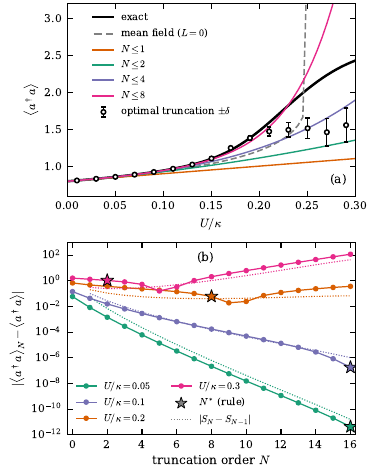

In [3]:
run("python3 assemble_truncation.py", "benchmarks/truncation", timeout=600)
run("python3 make_figures.py kerr", "engines", timeout=1200)
paper_figure("benchmarks/truncation/fig_kerr_convergence.pdf")

In [4]:
K = J("benchmarks", "truncation", "truncation_results.json")["kerr_cavity"]["results"]
n = J("engines", "numbers.json")
print("Sec. V.A")
quoted("U=0.2: mean-field <a^dag a>", 1.215, n['kerr_exact_vs_mf']['0.20'][1]); quoted("U=0.2: exact", 1.485, K['0.20']['exact'])
quoted("U=0.3: mean-field", 3.76, n['kerr_exact_vs_mf']['0.30'][1]); quoted("U=0.3: exact", 2.43, K['0.30']['exact'])
c = n["kerr_coeffs"]; quoted("root test |c_N|^(-1/N) at N=10", 0.27, abs(c[10])**(-0.1))
for U, pd, pt in (("0.05", 1.6e-11, 4.3e-12), ("0.10", 1.0e-6, 1.8e-7), ("0.20", 0.041, 0.061), ("0.30", 0.25, 1.08)):
    r = K[U]; quoted(f"U={U}: N*={r['N_star']}, delta", pd, r['delta'], "{:.2g}"); quoted(f"U={U}: true error at N*", pt, r['true_error'], "{:.2g}")
quoted("U=0.2: minimum error (at N=9)", 0.019, min(K['0.20']['true_error_all_orders']), "{:.3f}")
quoted("U=0.3: minimum error (at N=5)", 0.16, min(K['0.30']['true_error_all_orders']), "{:.2f}")

Sec. V.A
  U=0.2: mean-field <a^dag a>                                    paper        1.215   code        1.215
  U=0.2: exact                                                   paper        1.485   code        1.485
  U=0.3: mean-field                                              paper         3.76   code        3.757
  U=0.3: exact                                                   paper         2.43   code        2.433
  root test |c_N|^(-1/N) at N=10                                 paper         0.27   code       0.2733
  U=0.05: N*=16, delta                                           paper      1.6e-11   code      1.6e-11
  U=0.05: true error at N*                                       paper      4.3e-12   code      4.3e-12
  U=0.10: N*=16, delta                                           paper        1e-06   code        1e-06
  U=0.10: true error at N*                                       paper      1.8e-07   code      1.8e-07
  U=0.20: N*=8, delta                                  